# Data-driven Adaptive Chirp Mode Decomposition (DD-ACMD)

**DD-ACMD** (Wang, Chen & Zhai, 2023) wraps classical **ACMD** in a fully data-driven outer loop:
no STFT ridge and no Fourier-peak IF seed are required. Instantaneous-frequency (IF) guesses
come from **derivative normalization (IF-DN)** plus iterative **time-varying low-pass (TVLP)** filtering.

**Reference**

> H. Wang, S. Chen, W. Zhai.  
> *Data-driven adaptive chirp mode decomposition with application to machine fault diagnosis under non-stationary conditions.*  
> Mechanical Systems and Signal Processing, 2023.  
> DOI / MSSP: [S0888327022010652](https://www.sciencedirect.com/science/article/abs/pii/S0888327022010652)

MATLAB code: [File Exchange 121373](https://www.mathworks.com/matlabcentral/fileexchange/121373).

## 1. Relationship to `ACMD` (`pysdkit._acmd.acmd`)

| | **ACMD** | **DD-ACMD** |
|---|---|---|
| Role | Inner **mode extractor** | Outer **recursive driver** |
| IF initialization | User / FFT peak / STFT ridge | **DDIFI** = IF-DN + TVLP |
| First mode | Oscillatory (peak IF) | **Trend** with $\mathrm{IF}_0 \equiv 0$ |
| Mode count | Fixed `K` | Auto-stop when $\varepsilon = \|r\|_2^2/\|s\|_2^2 < \tau$ |
| Residual prep | Subtract mode only | Subtract + **TVLP** before next IF-DN |

In code, `DD_ACMD` constructs an `ACMD(K=1, …)` instance and calls `extract_mode(residual, init_if)` —
the variational demodulation / arctangent IF update is **exactly** the same as in `acmd.py`.
DD-ACMD only changes **how `init_if` is built** and **when recursion stops**.

## 2. Core principles & formulas

### 2.1 Chirp mode model (shared with ACMD)

Each mode is an AM–FM chirp

$$
s_k(t) = a_k(t)\,\cos\!\Bigl(2\pi \int_0^t f_k(\tau)\,d\tau\Bigr),
$$

demodulated against a kernel built from the current IF guess $f_k^{(\ell)}(t)$:

$$
\mathbf{K} = \bigl[\mathrm{diag}(\cos\phi),\;\mathrm{diag}(\sin\phi)\bigr],
\quad
\phi(t)=2\pi\int_0^t f_k^{(\ell)}(\tau)\,d\tau.
$$

ACMD solves a Tikhonov problem for the demodulated pair $(y_c,y_s)$, reconstructs
$\hat s = \mathbf{K}\mathbf{y}$, then updates

$$
\Delta f = \frac{y_c\,\dot y_s - y_s\,\dot y_c}{2\pi\,(y_c^2+y_s^2)},
\qquad
f \leftarrow f - \mathcal{S}_\beta(\Delta f)
$$

with a second-order smoothing operator $\mathcal{S}_\beta$ (same as `ACMD.iter`).

### 2.2 Derivative-normalization IF (IF-DN)

1. Differentiate the residual: $x'(t)$.
2. Between consecutive extrema of $x'$, normalize to a local cosine:
   $g(t)=(x'-m)/A \in [-1,1]$.
3. Recover phase by the package’s piecewise $\arccos$ (slope-folding), then
   $f_{\mathrm{DN}}(t)=\frac{d}{dt}\theta(t)$, smoothed by $\mathcal{S}_\beta$.

Differentiating emphasizes **higher-frequency** content, so modes tend to appear
**high → low** after the trend.

### 2.3 Time-varying low-pass (TVLP)

$$
\tilde x(t)=x_a(t)\,e^{-j\psi(t)},
\quad
\psi(t)=2\pi\int_0^t\bigl(f(\tau)-f_c\bigr)\,d\tau,
$$

FIR-lowpass $\tilde x$ at $\approx 1.1\,f_c$, then remodulate.  This peels the
just-estimated band so the next IF-DN sees the remaining mixture.

### 2.4 Outer DD-ACMD loop

1. **Trend:** ACMD with $f^{(0)}\equiv 0$.
2. **DDIFI:** iterate IF-DN → TVLP until $\|f\|_2$ stabilizes → `init_if`.
3. **ACMD** with that seed; subtract mode.
4. Stop if $\varepsilon<\tau$ (default $0.01$); else TVLP residual and goto 2.

## 3. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import ACMD, DD_ACMD
from pysdkit._acmd.dd_acmd import (
    generate_stationary_demo,
    generate_nonstationary_demo,
    generate_close_modes_demo,
    data_driven_if_init,
)
from pysdkit._acmd.acmd import compute_snr, stft, tf_spectrum

print(DD_ACMD(fs=300))
print("Inner extractor:", ACMD(K=1, fs=300))

Data-driven Adaptive Chirp Mode Decomposition (DD-ACMD)
Inner extractor: Adaptive Chirp Mode Decomposition (ACMD)


## 4. Example A — Stationary mixture (MATLAB `1.Stationary signal/Test.m`)

Quadratic trend + three tones at 20 / 25 / 30 Hz with mild noise.

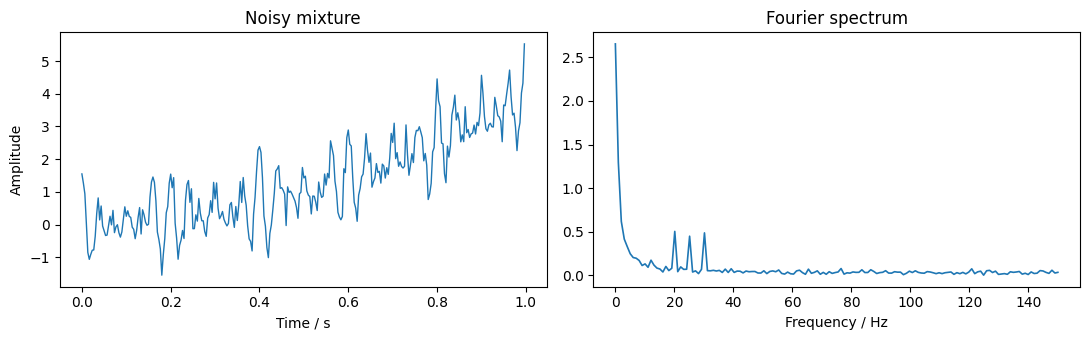

In [2]:
demo = generate_stationary_demo(
    fs=300.0, duration=1.0, noise_std=0.3, rng=np.random.default_rng(0)
)
t, fs, sig = demo["t"], demo["fs"], demo["signal"]
modes_true, ifs_true = demo["modes"], demo["ifs"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t, sig, lw=1.0)
axes[0].set_xlabel("Time / s")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Noisy mixture")

spec = 2 * np.abs(np.fft.fft(sig)) / len(sig)
half = int(len(sig) / 2.0 + 0.5)
freq = np.linspace(0, fs / 2, half)
axes[1].plot(freq, spec[:half], lw=1.2)
axes[1].set_xlabel("Frequency / Hz")
axes[1].set_title("Fourier spectrum")
fig.tight_layout()
plt.show()

In [3]:
dd = DD_ACMD(
    fs=fs,
    k_max=8,
    alpha0=1e-7,
    beta=1e-10,
    tol=1e-12,
    max_iter=120,
    energy_tol=0.01,
    ddifi_max_iter=8,
)
imfs, ini_ifs, e_ifs, e_ias = dd.fit_transform(sig, return_all=True)
print(f"Extracted K = {imfs.shape[0]} modes (incl. trend)")

# Match true tones (20/25/30 Hz) to estimated oscillatory modes by median IF
osc = slice(1, None)  # skip trend
for name, true_m, f0 in [
    ("20 Hz", modes_true[1], 20.0),
    ("25 Hz", modes_true[2], 25.0),
    ("30 Hz", modes_true[3], 30.0),
]:
    j = (
        int(np.argmin([abs(np.median(e_ifs[i]) - f0) for i in range(1, imfs.shape[0])]))
        + 1
    )
    print(
        f"{name}: matched mode {j}, median IF={np.median(e_ifs[j]):.2f} Hz, "
        f"SNR={compute_snr(true_m, imfs[j]):.2f} dB"
    )

Extracted K = 4 modes (incl. trend)
20 Hz: matched mode 3, median IF=20.04 Hz, SNR=16.51 dB
25 Hz: matched mode 2, median IF=25.06 Hz, SNR=15.84 dB
30 Hz: matched mode 1, median IF=30.08 Hz, SNR=16.02 dB


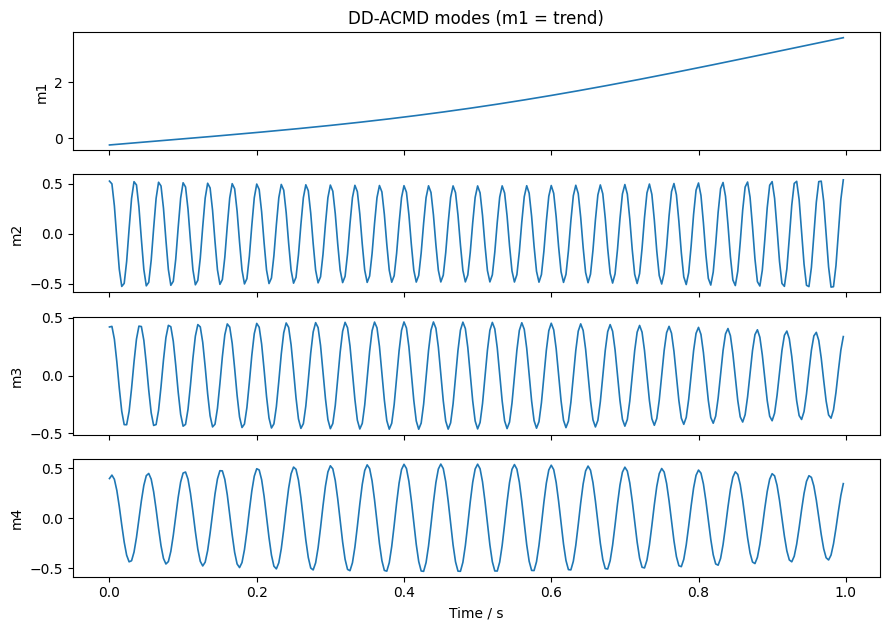

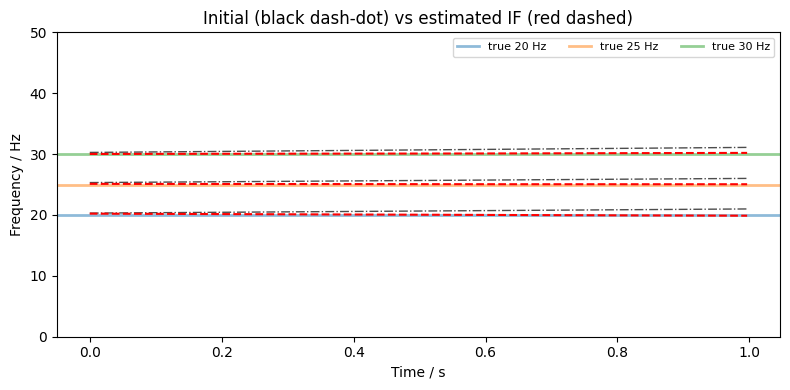

In [4]:
fig, axes = plt.subplots(
    imfs.shape[0], 1, figsize=(9, 1.6 * imfs.shape[0]), sharex=True
)
if imfs.shape[0] == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t, imfs[i], lw=1.2)
    ax.set_ylabel(f"m{i+1}")
axes[0].set_title("DD-ACMD modes (m1 = trend)")
axes[-1].set_xlabel("Time / s")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for f0, c in zip([20, 25, 30], ["C0", "C1", "C2"]):
    ax.axhline(f0, color=c, ls="-", lw=2, alpha=0.5, label=f"true {f0} Hz")
for i in range(1, min(imfs.shape[0], 4)):
    ax.plot(t, ini_ifs[i], "k-.", lw=1.0, alpha=0.7)
    ax.plot(t, e_ifs[i], "r--", lw=1.5)
ax.set_ylim(0, 50)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Initial (black dash-dot) vs estimated IF (red dashed)")
ax.legend(loc="upper right", ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

## 5. Example B — Noisy non-stationary chirps (MATLAB `2.Noisy non-stationary signal`)

Three polynomial chirps with sinusoidal IF modulation + noise.  We use a **shortened**
record for notebook runtime; increase `duration` / `max_iter` to match the paper demo.

K = 6


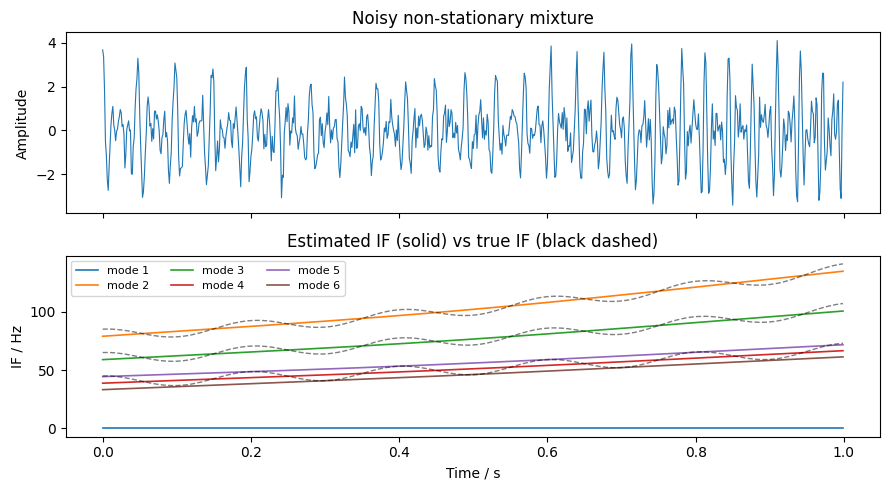

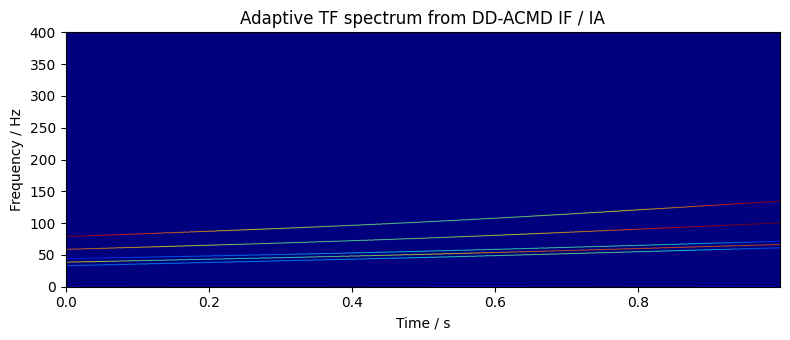

In [5]:
demo2 = generate_nonstationary_demo(
    fs=800.0, duration=1.0, noise_std=0.4, rng=np.random.default_rng(1)
)
t2, fs2, sig2 = demo2["t"], demo2["fs"], demo2["signal"]

dd2 = DD_ACMD(
    fs=fs2,
    k_max=6,
    max_iter=80,
    tol=1e-10,
    energy_tol=0.02,
    ddifi_max_iter=5,
)
imfs2, ini2, eif2, eia2 = dd2.fit_transform(sig2, return_all=True)
print(f"K = {imfs2.shape[0]}")

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t2, sig2, lw=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Noisy non-stationary mixture")
for i in range(imfs2.shape[0]):
    axes[1].plot(t2, eif2[i], lw=1.2, label=f"mode {i+1}")
for i, true_if in enumerate(demo2["ifs"]):
    axes[1].plot(t2, true_if, "k--", lw=1.0, alpha=0.5)
axes[1].set_ylabel("IF / Hz")
axes[1].set_xlabel("Time / s")
axes[1].legend(loc="upper left", fontsize=8, ncol=3)
axes[1].set_title("Estimated IF (solid) vs true IF (black dashed)")
fig.tight_layout()
plt.show()

band = (0.0, fs2 / 2.0)
a_spec, fbin = tf_spectrum(eif2, eia2, band=band)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.imshow(
    np.abs(a_spec),
    extent=[t2[0], t2[-1], fbin[0], fbin[-1]],
    aspect="auto",
    origin="lower",
    cmap="jet",
)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Adaptive TF spectrum from DD-ACMD IF / IA")
fig.tight_layout()
plt.show()

## 6. Example C — Signal with close modes (MATLAB `3.Signal with close modes/Test.m`)

Three closely spaced polynomial chirps (IF centres near 100 / 90 / 80 Hz) with exponential amplitude decay and **no noise** — a hard case for ridge-based methods. Parameters match the MATLAB demo: `SampFreq = 800`, duration 2 s.

In [ ]:
demo3 = generate_close_modes_demo(fs=800.0, duration=2.0, noise_std=0.0)
t3, fs3, sig3 = demo3["t"], demo3["fs"], demo3["signal"]
modes3, ifs3_true = demo3["modes"], demo3["ifs"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(t3, sig3, "b-", lw=0.9)
axes[0].set_xlim(0, 2)
axes[0].set_ylim(-4, 4)
axes[0].set_xlabel("Time / s")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Close-mode mixture (no noise)")

tf_spec3, f_stft3 = stft(sig3, fs3, n_fft=512, win_len=218)
axes[1].imshow(
    np.abs(tf_spec3),
    extent=[t3[0], t3[-1], f_stft3[0], f_stft3[-1]],
    aspect="auto",
    origin="lower",
    cmap="jet",
)
axes[1].set_ylim(0, 400)
axes[1].set_xlabel("Time / s")
axes[1].set_ylabel("Frequency / Hz")
axes[1].set_title("STFT")
fig.tight_layout()
plt.show()

In [ ]:
dd3 = DD_ACMD(
    fs=fs3,
    k_max=6,
    alpha0=1e-7,
    beta=1e-10,
    tol=1e-12,
    max_iter=120,
    energy_tol=0.01,
    ddifi_max_iter=8,
)
imfs3, ini3, eif3, eia3 = dd3.fit_transform(sig3, return_all=True)
print(f"Extracted K = {imfs3.shape[0]} modes")


# Match each true chirp to the nearest estimated IF (skip near-zero trend if present)
def _match_mode(true_if, eifs):
    errs = [
        np.linalg.norm(eifs[i] - true_if) / (np.linalg.norm(true_if) + 1e-12)
        for i in range(eifs.shape[0])
    ]
    return int(np.argmin(errs))


fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C0", "C1", "C2"]
for k, (true_if, true_m) in enumerate(zip(ifs3_true, modes3)):
    j = _match_mode(true_if, eif3)
    ax.plot(t3, true_if, colors[k], lw=2.0, label=f"true IF{k+1}")
    ax.plot(t3, ini3[j], "k-.", lw=1.0, alpha=0.7)
    ax.plot(t3, eif3[j], "r--", lw=1.5)
    snr = compute_snr(true_m, imfs3[j])
    print(
        f"Chirp {k+1}: matched mode {j+1}, IF RE={np.linalg.norm(eif3[j]-true_if)/np.linalg.norm(true_if):.4f}, SNR={snr:.2f} dB"
    )
ax.set_xlim(0, 2)
ax.set_ylim(0, 400)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Close modes — true IF (solid) / init IF (black) / estimated IF (red)")
ax.legend(loc="upper right", fontsize=8, ncol=3)
fig.tight_layout()
plt.show()

In [ ]:
# Reconstructed modes vs true components (matched by IF)
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for k, (ax, true_m, true_if) in enumerate(zip(axes, modes3, ifs3_true)):
    j = _match_mode(true_if, eif3)
    ax.plot(t3, imfs3[j], "b-", lw=1.0, label="estimated")
    ax.plot(t3, true_m - imfs3[j], "k--", lw=0.9, label="error")
    ax.set_ylabel(f"m{k+1}")
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(0, 2)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Reconstructed close modes (blue) and error (black dashed)")
axes[-1].set_xlabel("Time / s")
fig.tight_layout()
plt.show()

# Adaptive TF spectrum from estimated IF / IA (use oscillatory modes only if trend present)
use = slice(0, min(3, eif3.shape[0]))
# Prefer the three matched oscillatory indices when a trend exists
matched = [_match_mode(ti, eif3) for ti in ifs3_true]
a_spec3, fbin3 = tf_spectrum(eif3[matched], eia3[matched], band=(0.0, fs3 / 2.0))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.imshow(
    np.abs(a_spec3),
    extent=[t3[0], t3[-1], fbin3[0], fbin3[-1]],
    aspect="auto",
    origin="lower",
    cmap="jet",
)
ax.set_ylim(0, 400)
ax.set_xlabel("Time / s")
ax.set_ylabel("Frequency / Hz")
ax.set_title("Adaptive TF spectrum (close modes)")
fig.tight_layout()
plt.show()

## 7. Peek at DDIFI alone

For a single-tone residual, `data_driven_if_init` should return a nearly constant IF near the tone frequency (approximate — IF-DN is not a parametric estimator).

median init IF ≈ 35.73 Hz (target 35 Hz)


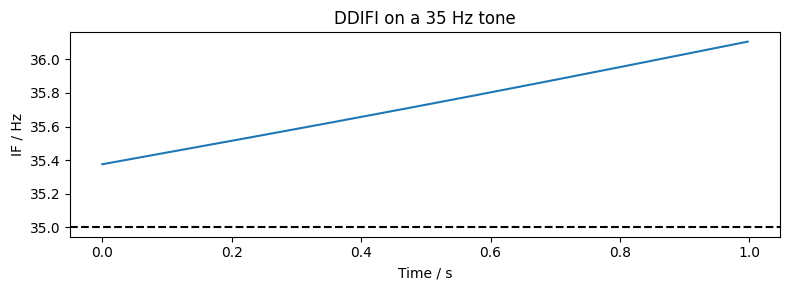

In [6]:
fs_p = 400.0
t_p = np.arange(0, 1.0, 1 / fs_p)
x_p = np.cos(2 * np.pi * 35 * t_p)
ini = data_driven_if_init(x_p, fs_p, beta=1e-10, max_iter=5)
print(f"median init IF ≈ {np.median(ini):.2f} Hz (target 35 Hz)")

plt.figure(figsize=(8, 3))
plt.plot(t_p, ini, lw=1.5)
plt.axhline(35, color="k", ls="--")
plt.xlabel("Time / s")
plt.ylabel("IF / Hz")
plt.title("DDIFI on a 35 Hz tone")
plt.tight_layout()
plt.show()

## 8. Practical notes

- Defaults mirror MATLAB DDACMD (`alpha0=1e-7`, `beta=1e-10`, `tol=1e-30`); a looser `tol` (e.g. `1e-10`) and smaller `max_iter` speed up demos with little loss.
- Mode **1** is the trend; oscillatory modes usually follow **high → low** IF order.
- For the close-modes demo, MATLAB plots the first three oscillatory IFs against the true chirps; if a near-zero trend appears first, match modes by median IF.
- TVLP uses the open MATLAB `low_filter` path (FIR, cutoff $1.1\,f_c$), not proprietary `lowpass`.
- Prefer `DD_ACMD` when IF seeds are unknown; prefer plain `ACMD` when a good IF trajectory (ridge / tachometer) is already available.